In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from typing import Union, Dict, Tuple
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### dataset prepare for baseline

In [6]:
# Loading the synthesized data
data = pd.read_csv('../data/01_raw/colombo_taxi_rides.csv')
data.shape


(8760, 11)

- **datetime** — hourly timestamp (one row per hour)

- **season** — Sri Lankan tropical calendar:
    - 1 = Dry Season (Dec, Jan, Feb, Mar)
    - 2 = Pre-Monsoon (Apr, May)
    - 3 = SW Monsoon / Wet Season (Jun, Jul, Aug, Sep)
    - 4 = Post-Monsoon (Oct, Nov)

- **hour** — hour of the day (0 = midnight … 23 = 11 PM)

- **holiday** — whether the day is a Sri Lankan public holiday (Poya days, Independence Day, Sinhala/Tamil New Year, Vesak, Christmas, etc.)
    - 0 = Regular day
    - 1 = Public holiday

- **weekday** — day number of the week (0 = Sunday … 6 = Saturday)

- **weathersit** — weather situation in Colombo:
    - 1: Clear / Partly Cloudy
    - 2: Mist + Cloudy
    - 3: Light Rain / Drizzle
    - 4: Heavy Rain / Thunderstorm

- **temp** — temperature in Celsius (Colombo range: 24 – 37 °C)
- **humidity** — relative humidity in % (Colombo range: 52 – 97 %)
- **windspeed** — wind speed in km/h (Colombo range: 2 – 38 km/h)
- **ride_count** — total taxi ride bookings in that hour across Colombo (range: ~80 – 5,000)

In [7]:
data.columns

Index(['id', 'datetime', 'season', 'hour', 'holiday', 'weekday', 'weathersit',
       'temp', 'humidity', 'windspeed', 'ride_count'],
      dtype='str')

In [10]:
drop_cols = ['id','datetime']

In [11]:
data = data.drop(columns=drop_cols)

In [12]:
data.head(3)

,season,hour,holiday,weekday,weathersit,temp,humidity,windspeed,ride_count
0,1,0,0,1,3,29.39,82.93,16.92,169
1,1,1,0,1,2,25.85,69.41,23.81,121
2,1,2,0,1,1,26.68,72.28,15.51,131


### Baseline Model

metrics
- MAPE
- MAE
- RMSE

In [13]:
def compute_metrics(
    y_true: Union[np.ndarray, list], 
    y_pred: Union[np.ndarray, list]
) -> Dict[str, float]:
    """
    Compute evaluation metrics between true and predicted values.

    Metrics returned:
    - MAPE: Mean Absolute Percentage Error (in %)
    - MAE: Mean Absolute Error
    - RMSE: Root Mean Squared Error

    Parameters:
    ----------
    y_true : array-like
        Ground truth values.
    y_pred : array-like
        Predicted values.

    Returns:
    -------
    dict
        Dictionary with keys 'MAPE', 'MAE', and 'RMSE' and their float values.
    """
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mape = np.mean(np.abs((y_true - y_pred) / y_true + 1e-8)) * 100

    return {
        'MAE': float(round(mae, 2)),
        'RMSE': float(round(rmse, 2)),
        'MAPE': float(round(mape, 2)),
    }

In [14]:
def prepare_dataset(
    df: pd.DataFrame, 
    train_fraction: float = 0.8
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Splits a DataFrame into training and testing sets for features and target.

    Parameters:
    ----------
    df : pd.DataFrame
        The input DataFrame that must contain a 'target' column.
    train_fraction : float, optional (default=0.8)
        The fraction of data to use for training (between 0 and 1).

    Returns:
    -------
    x_train : pd.DataFrame
        Training features.
    x_test : pd.DataFrame
        Testing features.
    y_train : pd.Series
        Training target values.
    y_test : pd.Series
        Testing target values.
    """
    feats = [col for col in df.columns if col != 'target']
    x, y = df[feats], df['target']
    train_size = int(train_fraction * df.shape[0])
    x_train, x_test = x[:train_size], x[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    return x_train, x_test, y_train, y_test

### Target definition

In [15]:
df = data.copy()

In [16]:
df['target'] = df['ride_count'].shift(-1).ffill()
df.drop(columns=['ride_count'], inplace=True)

In [17]:
df.head(3)

,season,hour,holiday,weekday,weathersit,temp,humidity,windspeed,target
0,1,0,0,1,3,29.39,82.93,16.92,121.0
1,1,1,0,1,2,25.85,69.41,23.81,131.0
2,1,2,0,1,1,26.68,72.28,15.51,70.0


### Fitting the model

In [18]:
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)

In [19]:
params = {
    'learning_rate': 0.2,
    'depth': 6,
    'l2_leaf_reg': 1,
    'iterations': 500,
    'loss_function': 'RMSE',
    'verbose': 0
}

np.random.seed(42)
model = CatBoostRegressor(**params, random_seed=42)

# Tuning with early stopping
model.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

### Baseline prediction

In [20]:
y_pred = model.predict(x_test)
compute_metrics(y_test.values, y_pred)

{'MAE': 249.4, 'RMSE': 360.12, 'MAPE': 30.96}

Text(0.5, 1.0, 'Ride Count, 1-h Forecast, Baseline')

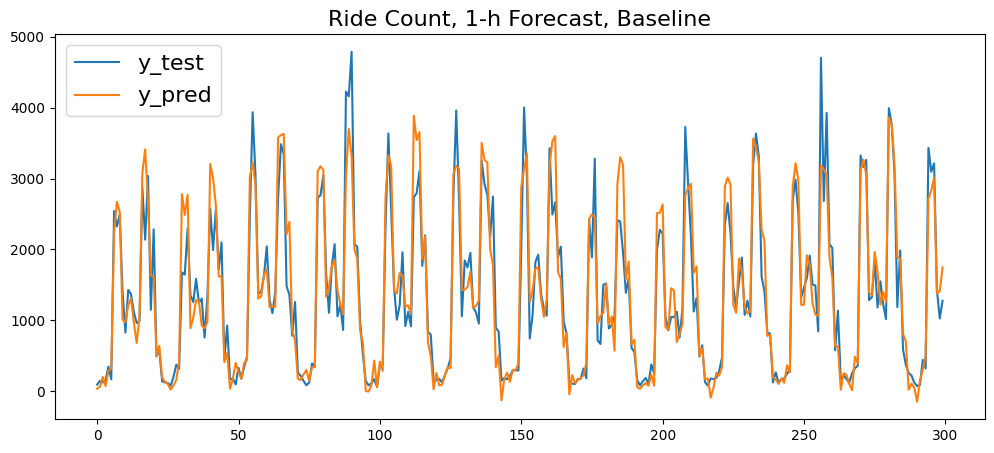

In [23]:
n = 300
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend(fontsize=16)
plt.title('Ride Count, 1-h Forecast, Baseline', fontsize=16)

# Baseline Model lag features

shifting y by one so that time trends (to learn from previous day , week behaviours etc.)

In [24]:
df = data.copy()
df['target'] = df['ride_count'].shift(-1).ffill()
df.head(3)

,season,hour,holiday,weekday,weathersit,temp,humidity,windspeed,ride_count,target
0,1,0,0,1,3,29.39,82.93,16.92,169,121.0
1,1,1,0,1,2,25.85,69.41,23.81,121,131.0
2,1,2,0,1,1,26.68,72.28,15.51,131,70.0


In [25]:
# Let's compute autocorrelation
for lag in range(1, 25):
    print(f"Lag {lag}: {df['target'].autocorr(lag=lag):.3f}")

Lag 1: 0.640
Lag 2: 0.364
Lag 3: 0.036
Lag 4: -0.042
Lag 5: -0.172
Lag 6: -0.266
Lag 7: -0.380
Lag 8: -0.261
Lag 9: -0.141
Lag 10: 0.066
Lag 11: 0.019
Lag 12: 0.073
Lag 13: 0.013
Lag 14: 0.058
Lag 15: -0.153
Lag 16: -0.274
Lag 17: -0.390
Lag 18: -0.280
Lag 19: -0.184
Lag 20: -0.056
Lag 21: 0.022
Lag 22: 0.342
Lag 23: 0.614
Lag 24: 0.883


#### Target Lags

high correlation in first two and last two

In [26]:
# Add first 2 lags
for i in range(1, 3):
    df[f'cnt_lag_{i}'] = df['ride_count'].shift(i).bfill()

# Add last 2 lags
for i in range(22, 24):
    df[f'cnt_lag_{i}'] = df['ride_count'].shift(i).bfill()

#### Other Feature Lags

In [29]:
lag_feats = ['hour', 'temp', 'humidity']

n = 3
for feat in lag_feats:
    for i in range(1, n+1):
        df[f'{feat}_lag_{i}'] = df[feat].shift(i).bfill()

In [30]:
df.head(3)

,season,hour,holiday,weekday,weathersit,temp,humidity,windspeed,ride_count,target,...,cnt_lag_23,hour_lag_1,hour_lag_2,hour_lag_3,temp_lag_1,temp_lag_2,temp_lag_3,humidity_lag_1,humidity_lag_2,humidity_lag_3
0,1,0,0,1,3,29.39,82.93,16.92,169,121.0,...,169.0,0.0,0.0,0.0,29.39,29.39,29.39,82.93,82.93,82.93
1,1,1,0,1,2,25.85,69.41,23.81,121,131.0,...,169.0,0.0,0.0,0.0,29.39,29.39,29.39,82.93,82.93,82.93
2,1,2,0,1,1,26.68,72.28,15.51,131,70.0,...,169.0,1.0,0.0,0.0,25.85,29.39,29.39,69.41,82.93,82.93


### Training the Model with Lags

In [31]:
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)

In [32]:
x_train.head(3)

,season,hour,holiday,weekday,weathersit,temp,humidity,windspeed,ride_count,cnt_lag_1,...,cnt_lag_23,hour_lag_1,hour_lag_2,hour_lag_3,temp_lag_1,temp_lag_2,temp_lag_3,humidity_lag_1,humidity_lag_2,humidity_lag_3
0,1,0,0,1,3,29.39,82.93,16.92,169,169.0,...,169.0,0.0,0.0,0.0,29.39,29.39,29.39,82.93,82.93,82.93
1,1,1,0,1,2,25.85,69.41,23.81,121,169.0,...,169.0,0.0,0.0,0.0,29.39,29.39,29.39,82.93,82.93,82.93
2,1,2,0,1,1,26.68,72.28,15.51,131,121.0,...,169.0,1.0,0.0,0.0,25.85,29.39,29.39,69.41,82.93,82.93


In [33]:
best_params = {
    'learning_rate': 0.2,
    'depth': 6,
    'l2_leaf_reg': 1,
    'iterations': 500,
    'loss_function': 'RMSE',
    'verbose': 0
}

np.random.seed(42)
model = CatBoostRegressor(**params, random_seed=42)

# Tuning with early stopping
model.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

In [34]:
y_pred = model.predict(x_test)
compute_metrics(y_test.values, y_pred)

{'MAE': 243.4, 'RMSE': 363.02, 'MAPE': 25.78}

Text(0.5, 1.0, 'Ride Count, 1-h Forecast, Model with Lags')

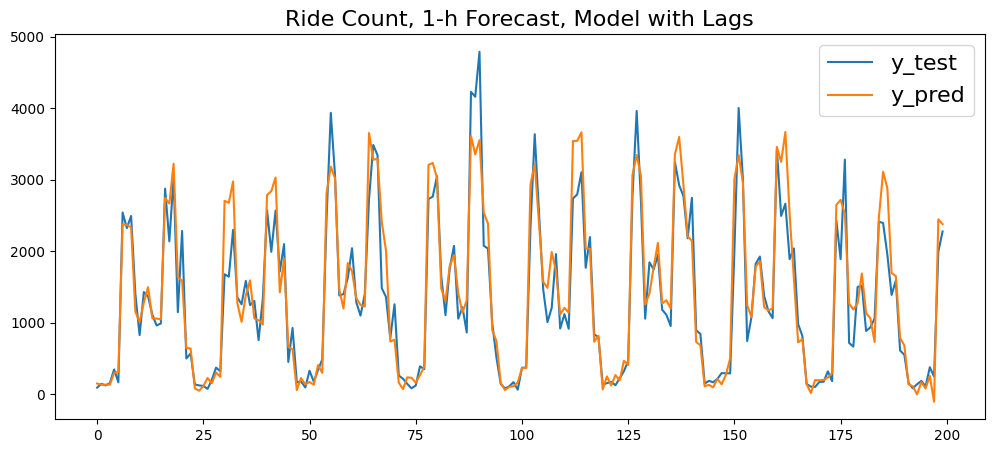

In [37]:
n = 200
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend(fontsize=16)
plt.title('Ride Count, 1-h Forecast, Model with Lags', fontsize=16)

In [36]:
# Save the model to experiments
model.save_model('../data/06_models/first_catboost_model.cbm')

# Conclusions

- The Baseline Gradient Boosting Model 
- Adding the target lags and feature lags improved the model 
